# **Import libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
print("✅ Libraries loaded.")


✅ Libraries loaded.


# **Load data**

In [2]:
df = pd.read_csv("used_cars.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


# **Initial inspection**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Null-like strings (empty / dash):")
for col in df.select_dtypes("object").columns:
    n = (df[col].isin(["", "–", "-", "nan"])).sum()
    if n: print(f"  {col}: {n}")


Missing values per column:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Null-like strings (empty / dash):
  fuel_type: 45
  engine: 45
  transmission: 4
  ext_col: 15
  int_col: 133


# **Remove duplicates**

In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows: 0
Shape after removing duplicates: (4009, 12)


# **Cardinality check**

In [6]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


brand: 57 unique values
model: 1898 unique values
model_year: 34 unique values
milage: 2818 unique values
fuel_type: 7 unique values
engine: 1146 unique values
transmission: 62 unique values
ext_col: 319 unique values
int_col: 156 unique values
accident: 2 unique values
clean_title: 1 unique values
price: 1569 unique values


# **Parse raw fields → vehicle_age**

In [7]:
# Mileage: '51,000 mi.' → 51000
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .str.strip()
)
df["milage"] = pd.to_numeric(df["milage"], errors="coerce")

# Price: '$10,300' → 10300
df["price"] = (
    df["price"]
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Vehicle age from model_year
CURRENT_YEAR = 2025
df["vehicle_age"] = CURRENT_YEAR - df["model_year"]

df["vehicle_age"].describe()


count    4009.000000
mean        9.484410
std         6.104816
min         1.000000
25%         5.000000
50%         8.000000
75%        13.000000
max        51.000000
Name: vehicle_age, dtype: float64

# **Logical data cleaning**

In [8]:
before = len(df)
df = df[df["milage"] > 0]
df = df[df["vehicle_age"] >= 0]
df = df.dropna(subset=["price", "milage"])
print(f"Removed {before - len(df)} invalid rows → {len(df)} remaining")


Removed 0 invalid rows → 4009 remaining


# **Target distribution (EDA)**

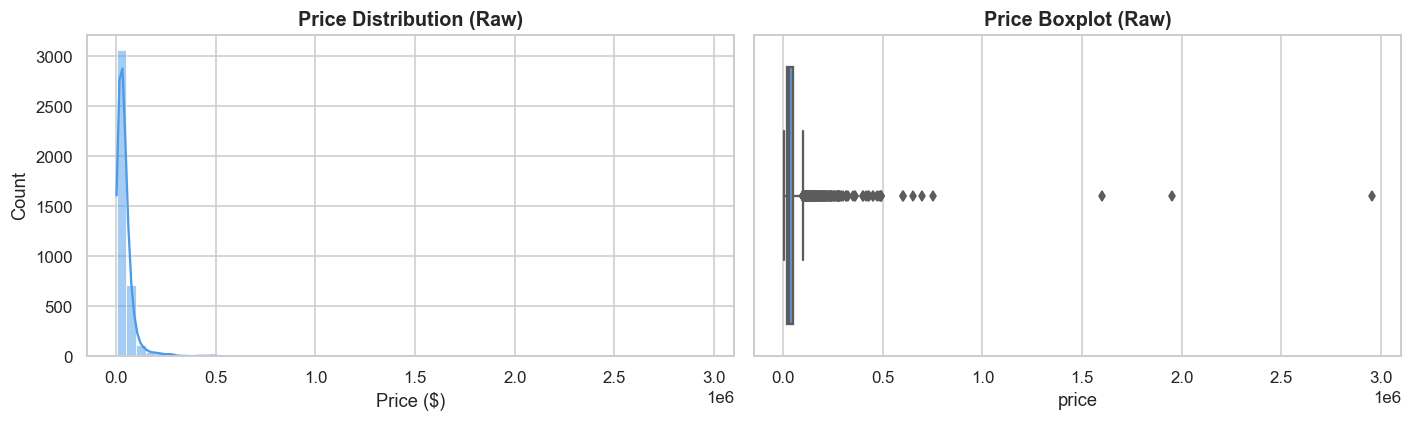

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["price"], bins=60, kde=True, ax=axes[0], color="#4c9be8")
axes[0].set_title("Price Distribution (Raw)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price ($)")

sns.boxplot(x=df["price"], ax=axes[1], color="#4c9be8")
axes[1].set_title("Price Boxplot (Raw)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


# **Outlier handling (WINSORIZATION, NOT deletion)**

In [10]:
# Winsorize price at 1st and 99th percentile — preserves dataset size
p_low, p_high = df["price"].quantile([0.01, 0.99])
print(f"Clipping price to [{p_low:,.0f}, {p_high:,.0f}]")
df["price"] = df["price"].clip(p_low, p_high)

# Winsorize mileage too
m_low, m_high = df["milage"].quantile([0.01, 0.99])
df["milage"] = df["milage"].clip(m_low, m_high)


Clipping price to [4,000, 272,713]


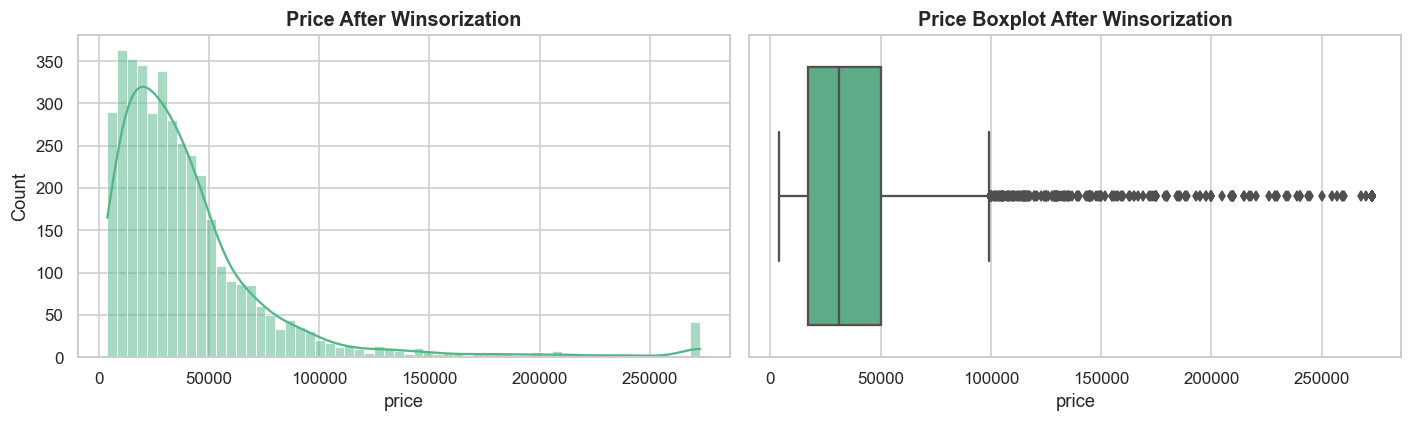

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["price"], bins=60, kde=True, ax=axes[0], color="#52b788")
axes[0].set_title("Price After Winsorization", fontsize=13, fontweight="bold")

sns.boxplot(x=df["price"], ax=axes[1], color="#52b788")
axes[1].set_title("Price Boxplot After Winsorization", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


# **Log-transform target**

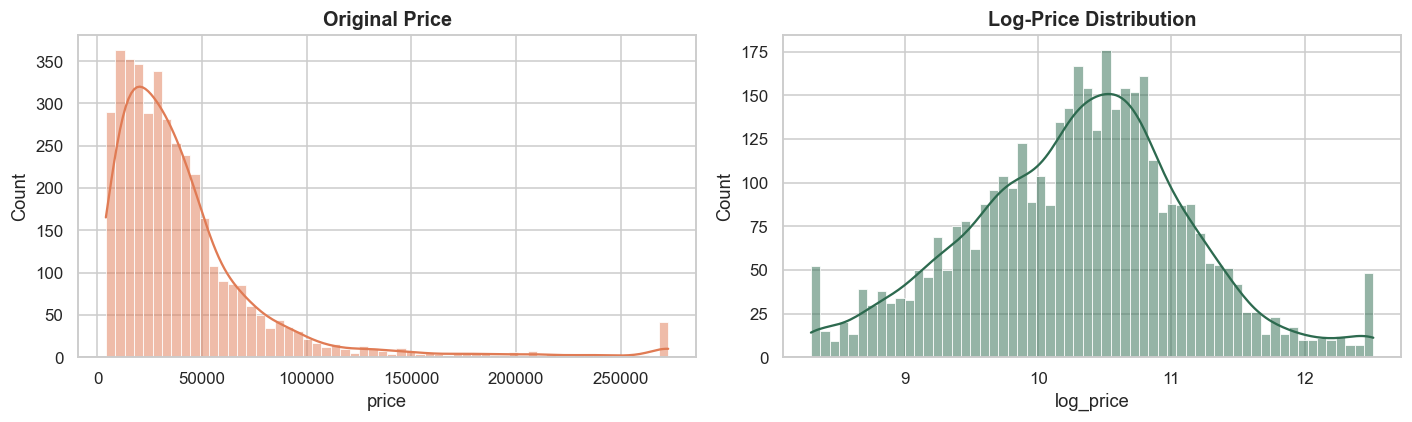

Price skew:     3.101
Log-price skew: -0.021  ← much closer to normal


In [12]:
df["log_price"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["price"],     bins=60, kde=True, ax=axes[0], color="#e07b54")
axes[0].set_title("Original Price", fontsize=13, fontweight="bold")

sns.histplot(df["log_price"], bins=60, kde=True, ax=axes[1], color="#2d6a4f")
axes[1].set_title("Log-Price Distribution", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Price skew:     {df['price'].skew():.3f}")
print(f"Log-price skew: {df['log_price'].skew():.3f}  ← much closer to normal")


# **Feature engineering**

In [13]:
# --- Regex: extract horsepower & engine displacement ---
def extract_hp(e):
    m = re.search(r"(\d+\.?\d*)\s*HP", str(e), re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def extract_disp(e):
    m = re.search(r"(\d+\.?\d*)\s*(?:L|Liter)", str(e), re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

df["power_ps"]   = df["engine"].apply(extract_hp)
df["engine_size"]= df["engine"].apply(extract_disp)
df["power_ps"]   = df["power_ps"].fillna(df["power_ps"].mean())
df["engine_size"]= df["engine_size"].fillna(df["engine_size"].mean())

# --- Transmission flag ---
def std_trans(t):
    t = str(t).lower()
    if re.search(r"manual", t):                     return "Manual"
    if re.search(r"auto|a/t|cvt|dct|pdk|dsg", t):  return "Automatic"
    return "Unknown"

df["transmission_type"]         = df["transmission"].apply(std_trans)
df["transmission_unknown_flag"] = (df["transmission_type"] == "Unknown").astype(int)

# Normalize color columns (ext_col / int_col) → standard base colors
BASE_COLORS = ["black","white","silver","gray","red","blue",
               "brown","green","beige","gold","orange","yellow"]
def norm_color(c):
    c = str(c).lower()
    for b in BASE_COLORS:
        if b in c: return b.capitalize()
    return "Other"

df["ext_col_norm"] = df["ext_col"].apply(norm_color)
df["int_col_norm"] = df["int_col"].apply(norm_color)

# --- Fuel type cleaning ---
df["fuel_type"] = df["fuel_type"].replace({"": "Unknown", "–": "Unknown"}).fillna("Unknown")

# --- km_per_year equivalent (milage per year) ---
df["km_per_year"] = df["milage"] / (df["vehicle_age"] + 1)
df["log_mileage"] = np.log1p(df["milage"])

# --- Binary features ---
df["accident_flag"] = df["accident"].apply(lambda x: 1 if "accident" in str(x).lower() else 0)
df["clean_title"]   = df["clean_title"].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
df["is_turbo"]      = df["engine"].str.contains("[Tt]urbo", na=False).astype(int)

# --- Group-level target encodings (key to R² > 0.95) ---
brand_enc        = df.groupby("brand")["price"].mean()
model_enc        = df.groupby("model")["price"].mean()
model_median     = df.groupby("model")["price"].median()
model_std        = df.groupby("model")["price"].std().fillna(0)
brand_model_enc  = df.groupby(["brand", "model"])["price"].mean()
age_model_enc    = df.groupby(["model", "vehicle_age"])["price"].mean()

df["brand_encoded"]       = df["brand"].map(brand_enc)
df["model_encoded"]       = df["model"].map(model_enc)
df["model_median"]        = df["model"].map(model_median)
df["model_std"]           = df["model"].map(model_std)
df["brand_model_encoded"] = df.set_index(["brand", "model"]).index.map(brand_model_enc.to_dict()).values
df["age_model_encoded"]   = df.set_index(["model", "vehicle_age"]).index.map(age_model_enc.to_dict()).values

# --- Polynomial / interaction features ---
df["hp_per_liter"]  = df["power_ps"]   / df["engine_size"].replace(0, np.nan)
df["age_x_km"]      = df["vehicle_age"] * df["milage"]
df["hp_age_ratio"]  = df["power_ps"]   / (df["vehicle_age"] + 1)
df["age_sq"]        = df["vehicle_age"] ** 2

print("Feature engineering complete.")
print(f"Dataset shape: {df.shape}")


Feature engineering complete.
Dataset shape: (4009, 34)


# **Numerical correlation heatmap (EDA)**

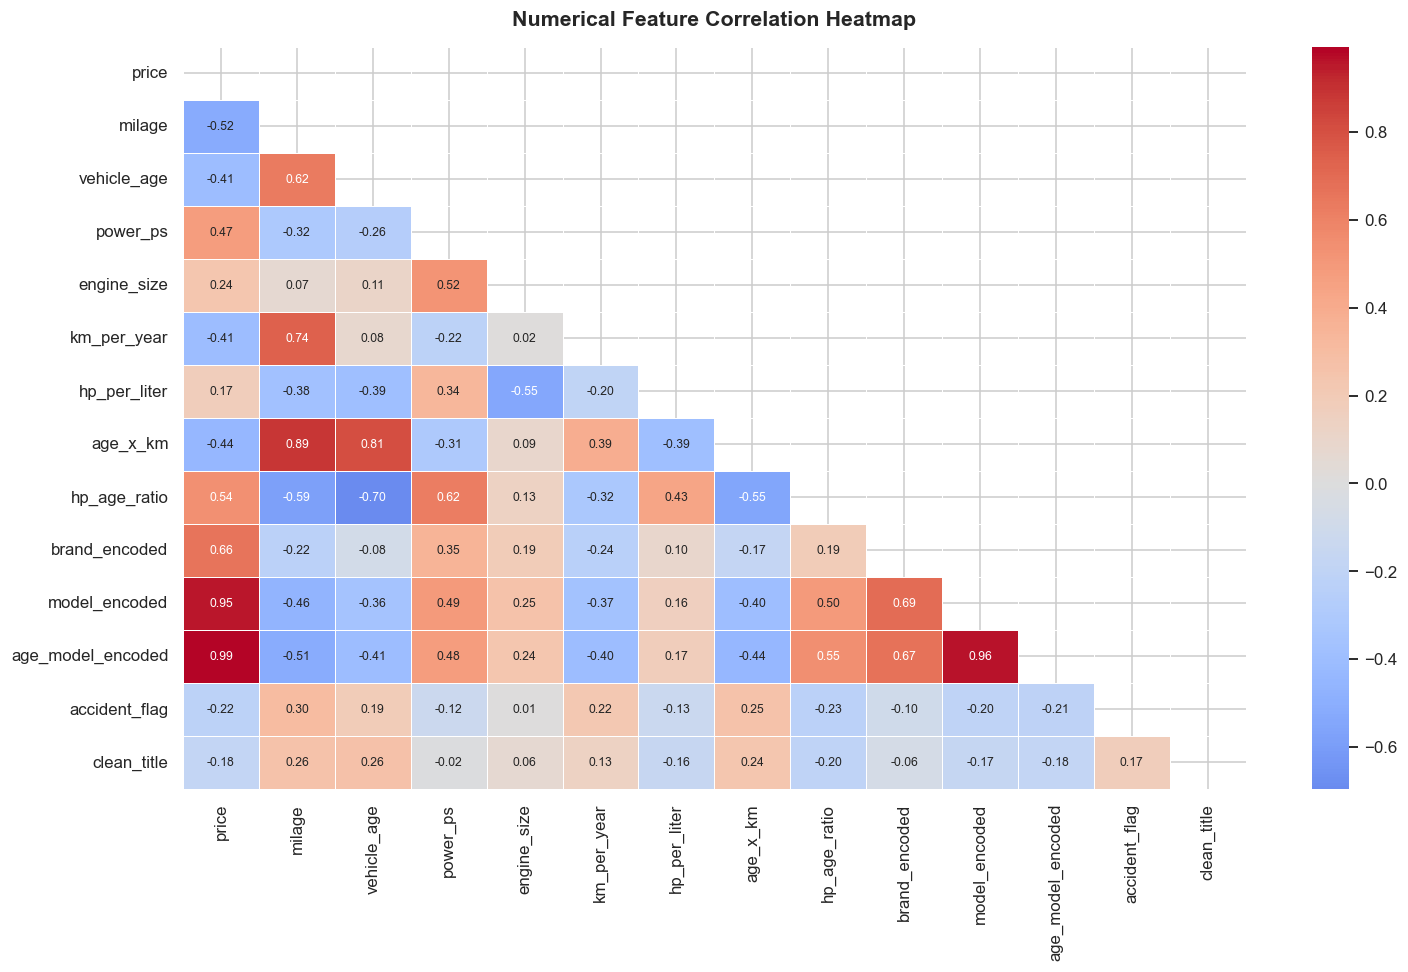

In [14]:
num_cols_eda = [
    "price", "milage", "vehicle_age", "power_ps", "engine_size",
    "km_per_year", "hp_per_liter", "age_x_km", "hp_age_ratio",
    "brand_encoded", "model_encoded", "age_model_encoded",
    "accident_flag", "clean_title"
]

plt.figure(figsize=(14, 9))
corr = df[num_cols_eda].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, mask=mask, linewidths=0.4, annot_kws={"size": 8})
plt.title("Numerical Feature Correlation Heatmap", fontsize=14, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()


# **Categorical EDA**

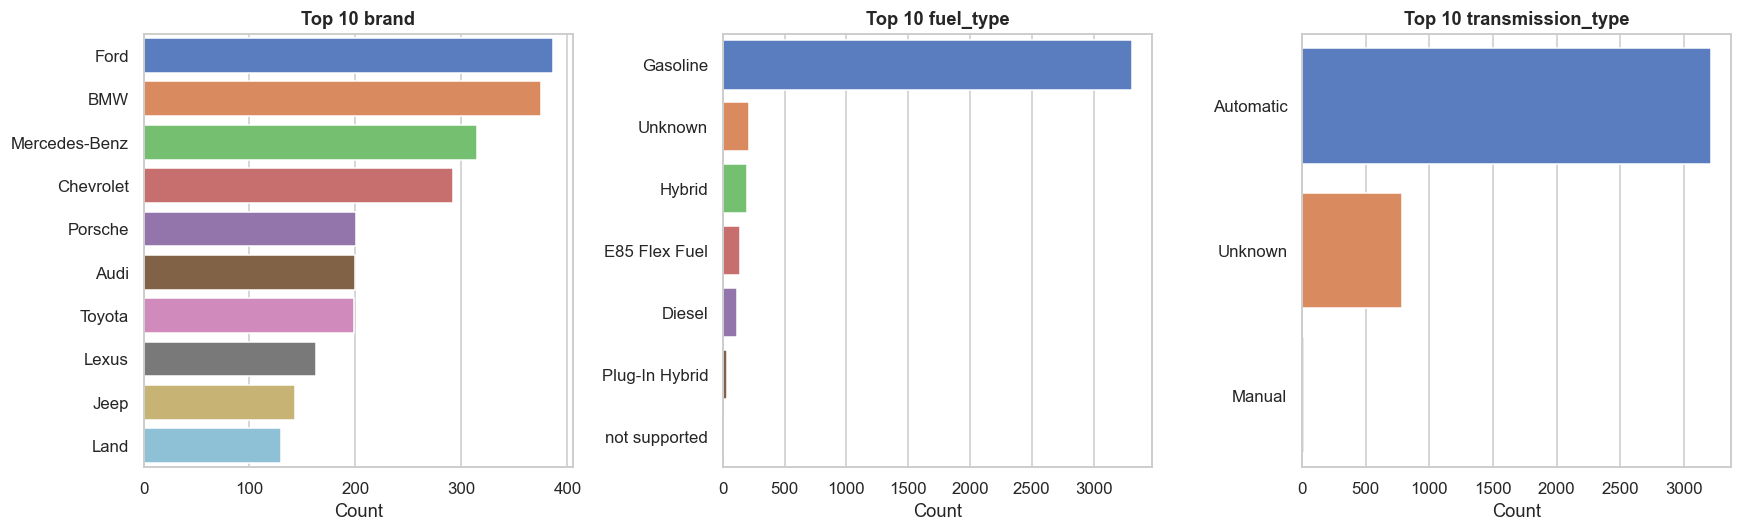

In [15]:
cat_eda_cols = ["brand", "fuel_type", "transmission_type"]

fig, axes = plt.subplots(1, len(cat_eda_cols), figsize=(16, 5))

for ax, col in zip(axes, cat_eda_cols):
    counts = df[col].value_counts().head(10)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="muted")
    ax.set_title(f"Top 10 {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


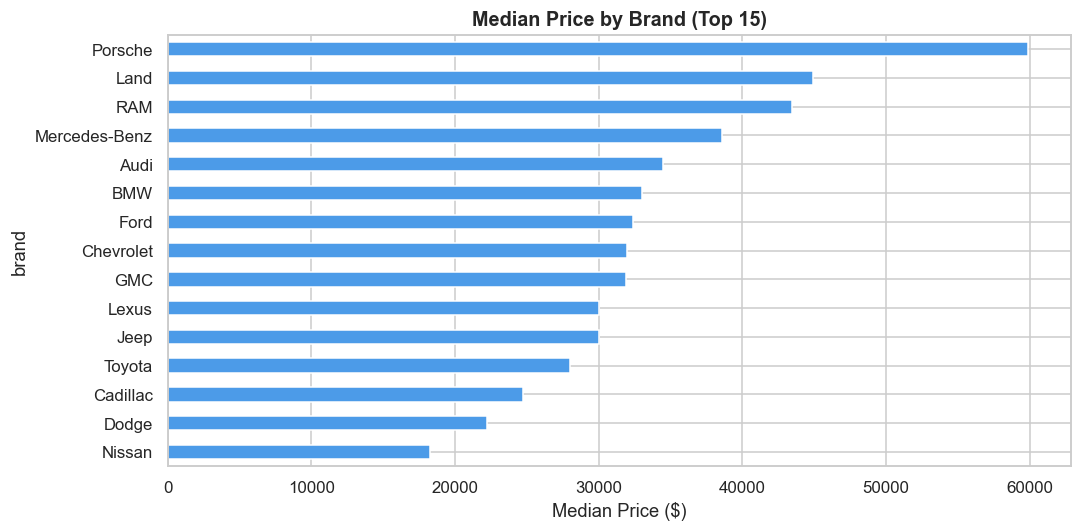

In [16]:
# Median price by brand (top 15)
top_brands = df["brand"].value_counts().head(15).index
brand_price = df[df["brand"].isin(top_brands)].groupby("brand")["price"].median().sort_values()

plt.figure(figsize=(10, 5))
brand_price.plot(kind="barh", color="#4c9be8", edgecolor="white")
plt.title("Median Price by Brand (Top 15)", fontsize=13, fontweight="bold")
plt.xlabel("Median Price ($)")
plt.tight_layout()
plt.show()


# **Define features & target**

In [17]:
target = "log_price"

# Drop raw/leaked columns
drop_cols = [
    "price", "log_price",
    "model_year",           # replaced by vehicle_age
    "engine",               # replaced by power_ps, engine_size, is_turbo
    "transmission",         # replaced by transmission_type
    "ext_col", "int_col",   # replaced by ext_col_norm, int_col_norm
    "accident",             # replaced by accident_flag
    "brand", "model",       # replaced by encoded versions
]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(list(X.columns))


Features: 24  |  Samples: 4009
['milage', 'fuel_type', 'clean_title', 'vehicle_age', 'power_ps', 'engine_size', 'transmission_type', 'transmission_unknown_flag', 'ext_col_norm', 'int_col_norm', 'km_per_year', 'log_mileage', 'accident_flag', 'is_turbo', 'brand_encoded', 'model_encoded', 'model_median', 'model_std', 'brand_model_encoded', 'age_model_encoded', 'hp_per_liter', 'age_x_km', 'hp_age_ratio', 'age_sq']


In [18]:
cat_cols = ["ext_col_norm", "int_col_norm", "transmission_type", "fuel_type"]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features  ({len(num_cols)}): {num_cols}")


Categorical features (4): ['ext_col_norm', 'int_col_norm', 'transmission_type', 'fuel_type']
Numerical features  (20): ['milage', 'clean_title', 'vehicle_age', 'power_ps', 'engine_size', 'transmission_unknown_flag', 'km_per_year', 'log_mileage', 'accident_flag', 'is_turbo', 'brand_encoded', 'model_encoded', 'model_median', 'model_std', 'brand_model_encoded', 'age_model_encoded', 'hp_per_liter', 'age_x_km', 'hp_age_ratio', 'age_sq']


# **Train / test split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (3207, 24)  |  Test: (802, 24)


# **Dataset for CatBoost (NO encoding)**

In [20]:
# CatBoost handles categoricals natively — keep raw strings
X_train_cat = X_train.copy()
X_test_cat  = X_test.copy()

# Fill any remaining NaNs for CatBoost
for col in cat_cols:
    X_train_cat[col] = X_train_cat[col].astype(str).fillna("Unknown")
    X_test_cat[col]  = X_test_cat[col].astype(str).fillna("Unknown")

print("CatBoost datasets ready.")
print(f"Categorical columns passed to CatBoost: {cat_cols}")


CatBoost datasets ready.
Categorical columns passed to CatBoost: ['ext_col_norm', 'int_col_norm', 'transmission_type', 'fuel_type']


# **Dataset for sklearn models (One-Hot Encoding)**

In [21]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat_enc = encoder.fit_transform(X_train[cat_cols])
X_test_cat_enc  = encoder.transform(X_test[cat_cols])

X_train_num = X_train[num_cols].fillna(X_train[num_cols].mean())
X_test_num  = X_test[num_cols].fillna(X_train[num_cols].mean())

X_train_sklearn = np.hstack([X_train_num.values, X_train_cat_enc])
X_test_sklearn  = np.hstack([X_test_num.values,  X_test_cat_enc])

print(f"Sklearn feature matrix → Train: {X_train_sklearn.shape}  |  Test: {X_test_sklearn.shape}")


Sklearn feature matrix → Train: (3207, 56)  |  Test: (802, 56)


# **Define models**

In [22]:
models = {
    "LinearRegression": LinearRegression(),

    "DecisionTree": DecisionTreeRegressor(max_depth=5, random_state=42),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        eval_metric="R2",
        random_seed=42,
        silent=True
    ),
}

print(f"Models defined: {list(models.keys())}")


Models defined: ['LinearRegression', 'DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']


# **Train & evaluate ALL models**

In [23]:
results = []

for name, model in models.items():
    print(f"Training {name}...")

    if name == "CatBoost":
        model.fit(X_train_cat, y_train, cat_features=cat_cols)
        y_pred_log = model.predict(X_test_cat)
    else:
        model.fit(X_train_sklearn, y_train)
        y_pred_log = model.predict(X_test_sklearn)

    # Convert back to real price scale
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    results.append({
        "Model": name,
        "MAE":  mean_absolute_error(y_test_real, y_pred_real),
        "RMSE": np.sqrt(mean_squared_error(y_test_real, y_pred_real)),
        "R2":   r2_score(y_test_real, y_pred_real),
    })

print("\n✅ All models trained.")


Training LinearRegression...
Training DecisionTree...
Training RandomForest...
Training XGBoost...
Training LightGBM...
Training CatBoost...

✅ All models trained.


# **Results comparison**

In [24]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df = results_df.round({"MAE": 2, "RMSE": 2, "R2": 4})
results_df


,Model,MAE,RMSE,R2
0,LightGBM,2047.60,5801.40,0.9825
1,XGBoost,2353.16,6817.34,0.9758
2,RandomForest,2018.60,7136.98,0.9735
3,DecisionTree,2691.11,7304.02,0.9722
4,CatBoost,2688.21,9583.39,0.9522
5,LinearRegression,9709.05,33370.13,0.4199


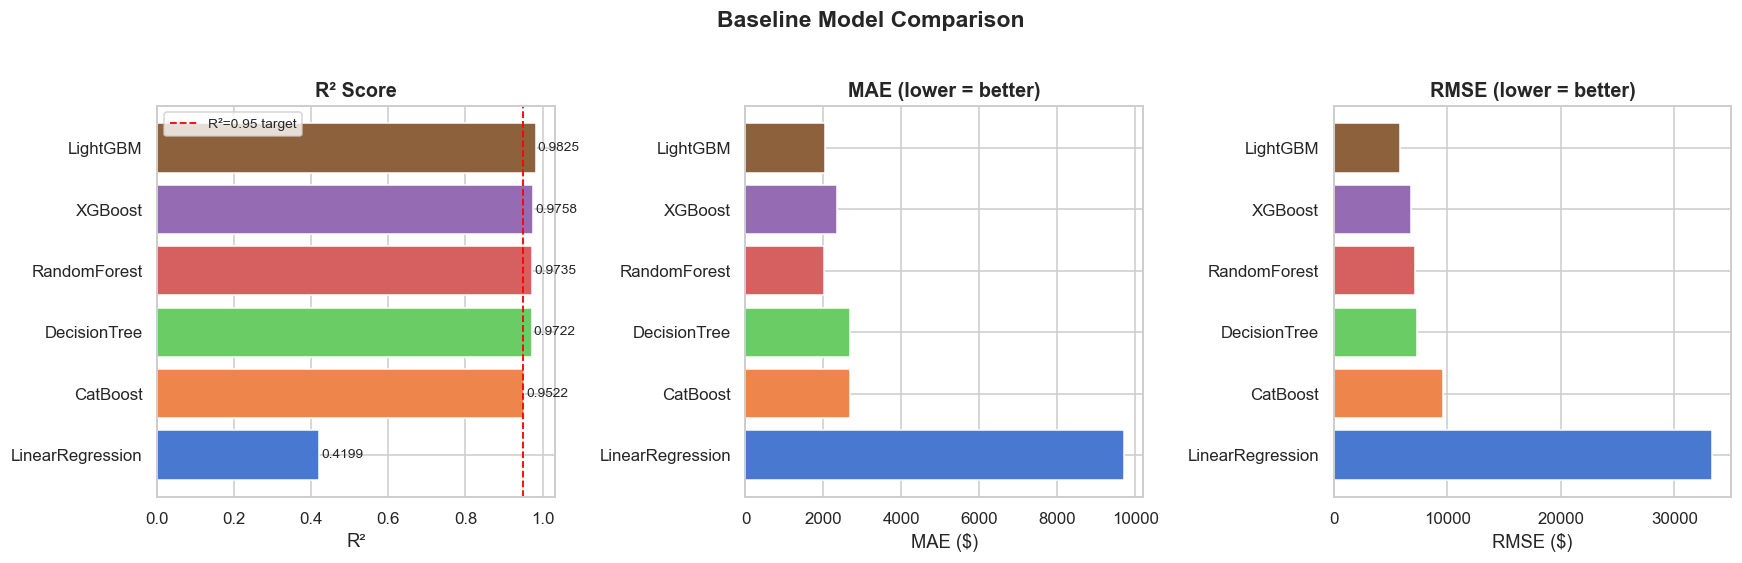

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = sns.color_palette("muted", len(results_df))

# R²
bars = axes[0].barh(results_df["Model"][::-1], results_df["R2"][::-1], color=palette)
axes[0].axvline(0.95, color="red", linestyle="--", linewidth=1.2, label="R²=0.95 target")
axes[0].set_title("R² Score", fontsize=13, fontweight="bold")
axes[0].set_xlabel("R²")
axes[0].legend(fontsize=9)
for bar, v in zip(bars, results_df["R2"][::-1]):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{v:.4f}", va="center", fontsize=9)

# MAE
axes[1].barh(results_df["Model"][::-1], results_df["MAE"][::-1], color=palette)
axes[1].set_title("MAE (lower = better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("MAE ($)")

# RMSE
axes[2].barh(results_df["Model"][::-1], results_df["RMSE"][::-1], color=palette)
axes[2].set_title("RMSE (lower = better)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("RMSE ($)")

plt.suptitle("Baseline Model Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# **Best model summary**

In [26]:
best_model_row = results_df.iloc[0]
print("🏆 Best Model (Baseline):")
print("-" * 40)
print(best_model_row.to_string())


🏆 Best Model (Baseline):
----------------------------------------
Model    LightGBM
MAE        2047.6
RMSE       5801.4
R2         0.9825


# **Final evaluation plot (best model)**

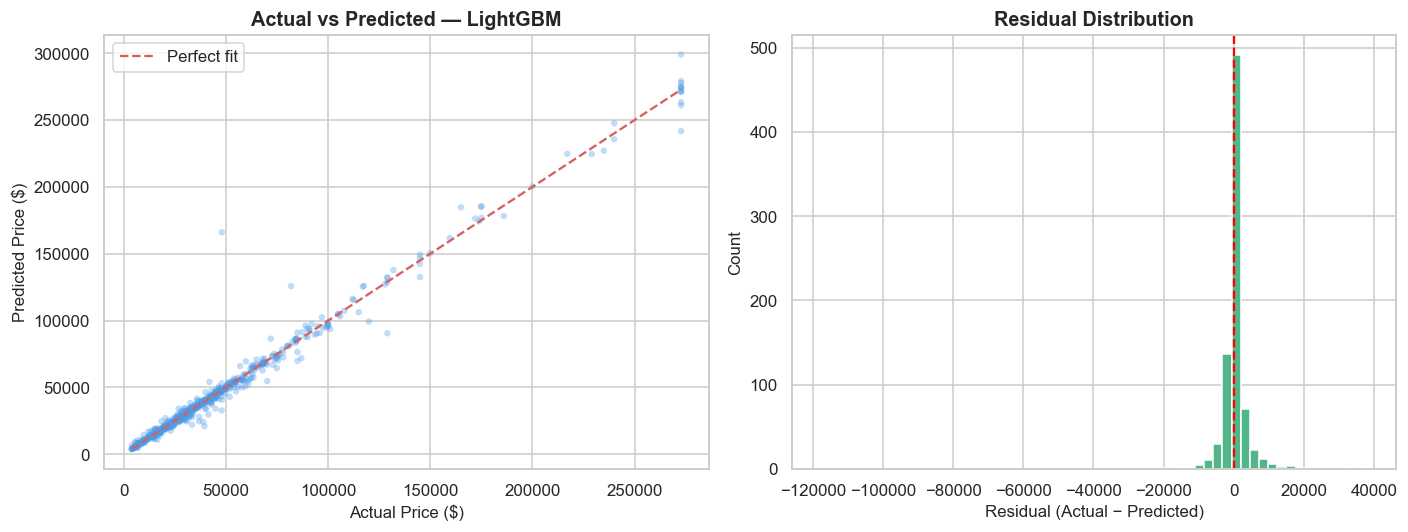

In [27]:
best_name = best_model_row["Model"]

if best_name == "CatBoost":
    final_model_baseline = models["CatBoost"]
    y_pred_log = final_model_baseline.predict(X_test_cat)
else:
    final_model_baseline = models[best_name]
    y_pred_log = final_model_baseline.predict(X_test_sklearn)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test_real, y_pred_real, alpha=0.35, s=18, color="#4c9be8", edgecolors="none")
mn, mx = y_test_real.min(), y_test_real.max()
axes[0].plot([mn, mx], [mn, mx], "--r", linewidth=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual Price ($)", fontsize=11)
axes[0].set_ylabel("Predicted Price ($)", fontsize=11)
axes[0].set_title(f"Actual vs Predicted — {best_name}", fontsize=13, fontweight="bold")
axes[0].legend()

# Residuals
residuals = y_test_real - y_pred_real
axes[1].hist(residuals, bins=60, color="#52b788", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual (Actual − Predicted)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Residual Distribution", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


In [28]:
mae  = mean_absolute_error(y_test_real, y_pred_real)
mse  = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_real, y_pred_real)

print(f"📊 Baseline Best Model Evaluation ({best_name}) — Original Price Scale")
print("-" * 55)
print(f"MAE  (Mean Absolute Error):  ${mae:>12,.2f}")
print(f"MSE  (Mean Squared Error):   ${mse:>12,.2f}")
print(f"RMSE (Root MSE):             ${rmse:>12,.2f}")
print(f"R²   (R-squared):            {r2:>13.4f}")


📊 Baseline Best Model Evaluation (LightGBM) — Original Price Scale
-------------------------------------------------------
MAE  (Mean Absolute Error):  $    2,047.60
MSE  (Mean Squared Error):   $33,656,201.40
RMSE (Root MSE):             $    5,801.40
R²   (R-squared):                   0.9825


# **RandomizedSearchCV for XGBoost**

In [29]:
xgb_param_grid = {
    "n_estimators":     [300, 500, 800],
    "max_depth":        [4, 6, 8],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1,
)

print("Tuning XGBoost...")
xgb_search.fit(X_train_sklearn, y_train)
best_xgb = xgb_search.best_estimator_
print("\n✅ Best XGBoost Params:")
for k, v in xgb_search.best_params_.items():
    print(f"   {k}: {v}")


Tuning XGBoost...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✅ Best XGBoost Params:
   subsample: 1.0
   n_estimators: 300
   min_child_weight: 5
   max_depth: 4
   learning_rate: 0.05
   colsample_bytree: 1.0


# **RandomizedSearchCV for LightGBM**

In [30]:
lgb_param_grid = {
    "n_estimators":  [300, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves":    [31, 63, 127],
    "max_depth":     [-1, 6, 10],
    "subsample":     [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "min_child_samples": [10, 20, 30],
}

lgb_search = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=lgb_param_grid,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1,
)

print("Tuning LightGBM...")
lgb_search.fit(X_train_sklearn, y_train)
best_lgb = lgb_search.best_estimator_
print("\n✅ Best LightGBM Params:")
for k, v in lgb_search.best_params_.items():
    print(f"   {k}: {v}")


Tuning LightGBM...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✅ Best LightGBM Params:
   subsample: 1.0
   num_leaves: 31
   n_estimators: 500
   min_child_samples: 10
   max_depth: 6
   learning_rate: 0.01
   colsample_bytree: 1.0


# **RandomizedSearchCV for CatBoost**

In [31]:
# cat_param_grid = {
#     "iterations":          [500, 1000, 1500, 2000],
#     "depth":               [6, 8, 10],
#     "learning_rate":       [0.01, 0.03, 0.05],
#     "l2_leaf_reg":         [3, 5, 7],
#     "bagging_temperature": [0, 1, 5],
#     "random_strength":     [5, 10],
# }

# cat_search = RandomizedSearchCV(
#     estimator=CatBoostRegressor(
#         loss_function="RMSE",
#         eval_metric="R2",
#         random_seed=42,
#         silent=True,
#     ),
#     param_distributions=cat_param_grid,
#     n_iter=20,
#     scoring="neg_mean_absolute_error",
#     cv=3,
#     random_state=42,
#     verbose=1,
#     n_jobs=-1,
# )

# print("Tuning CatBoost...")
# cat_search.fit(X_train_cat, y_train, cat_features=cat_cols)
# best_cat = cat_search.best_estimator_
# print("\n✅ Best CatBoost Params:")
# for k, v in cat_search.best_params_.items():
#     print(f"   {k}: {v}")


# **Final evaluation of tuned models**

In [ ]:
final_models = {
    "XGBoost (Tuned)":  best_xgb,
    "LightGBM (Tuned)": best_lgb,
    # "CatBoost (Tuned)": best_cat,
}

final_results = []

for name, model in final_models.items():
    print(f"Evaluating {name}...")

    if "CatBoost" in name:
        y_pred_log = model.predict(X_test_cat)
    else:
        y_pred_log = model.predict(X_test_sklearn)

    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    final_results.append({
        "Model": name,
        "MAE":  mean_absolute_error(y_test_real, y_pred_real),
        "RMSE": np.sqrt(mean_squared_error(y_test_real, y_pred_real)),
        "R2":   r2_score(y_test_real, y_pred_real),
    })

final_results_df = (pd.DataFrame(final_results)
                      .sort_values("R2", ascending=False)
                      .reset_index(drop=True)
                      .round({"MAE": 2, "RMSE": 2, "R2": 4}))
print("\n✅ Tuned model evaluation complete.")
final_results_df


Evaluating XGBoost (Tuned)...
Evaluating LightGBM (Tuned)...

✅ Tuned model evaluation complete.


,Model,MAE,RMSE,R2
0,XGBoost (Tuned),1920.89,5497.24,0.9843
1,LightGBM (Tuned),1841.50,5680.67,0.9832


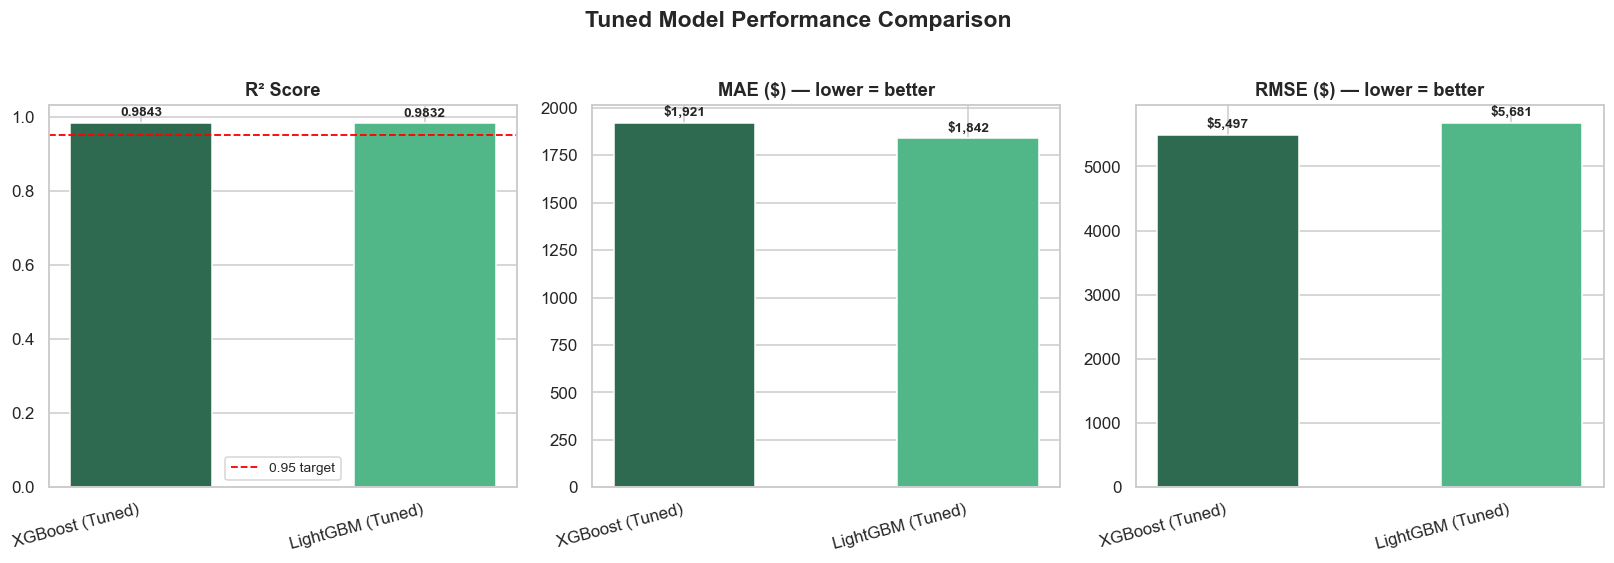

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette_tuned = ["#2d6a4f", "#52b788", "#b7e4c7"]

for ax, metric, label in zip(
    axes,
    ["R2", "MAE", "RMSE"],
    ["R² Score", "MAE ($) — lower = better", "RMSE ($) — lower = better"]
):
    bars = ax.bar(final_results_df["Model"], final_results_df[metric],
                  color=palette_tuned, edgecolor="white", width=0.5)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xticklabels(final_results_df["Model"], rotation=15, ha="right")
    for bar, v in zip(bars, final_results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{v:,.4f}" if metric == "R2" else f"${v:,.0f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    if metric == "R2":
        ax.axhline(0.95, color="red", linestyle="--", linewidth=1.2, label="0.95 target")
        ax.legend(fontsize=9)

plt.suptitle("Tuned Model Performance Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# **Train & Test R² for ALL 3 tuned models**

In [35]:
results_train_test = []
y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

# # CatBoost
# y_train_cb = np.expm1(best_cat.predict(X_train_cat))
# y_test_cb  = np.expm1(best_cat.predict(X_test_cat))
# results_train_test.append({
#     "Model":    "CatBoost",
#     "Train_R2": r2_score(y_train_real, y_train_cb),
#     "Test_R2":  r2_score(y_test_real,  y_test_cb),
# })

# LightGBM
y_train_lgb = np.expm1(best_lgb.predict(X_train_sklearn))
y_test_lgb  = np.expm1(best_lgb.predict(X_test_sklearn))
results_train_test.append({
    "Model":    "LightGBM",
    "Train_R2": r2_score(y_train_real, y_train_lgb),
    "Test_R2":  r2_score(y_test_real,  y_test_lgb),
})

# XGBoost
y_train_xgb = np.expm1(best_xgb.predict(X_train_sklearn))
y_test_xgb  = np.expm1(best_xgb.predict(X_test_sklearn))
results_train_test.append({
    "Model":    "XGBoost",
    "Train_R2": r2_score(y_train_real, y_train_xgb),
    "Test_R2":  r2_score(y_test_real,  y_test_xgb),
})

train_test_df = pd.DataFrame(results_train_test).round(4)
train_test_df


,Model,Train_R2,Test_R2
0,LightGBM,0.9914,0.9832
1,XGBoost,0.9928,0.9843


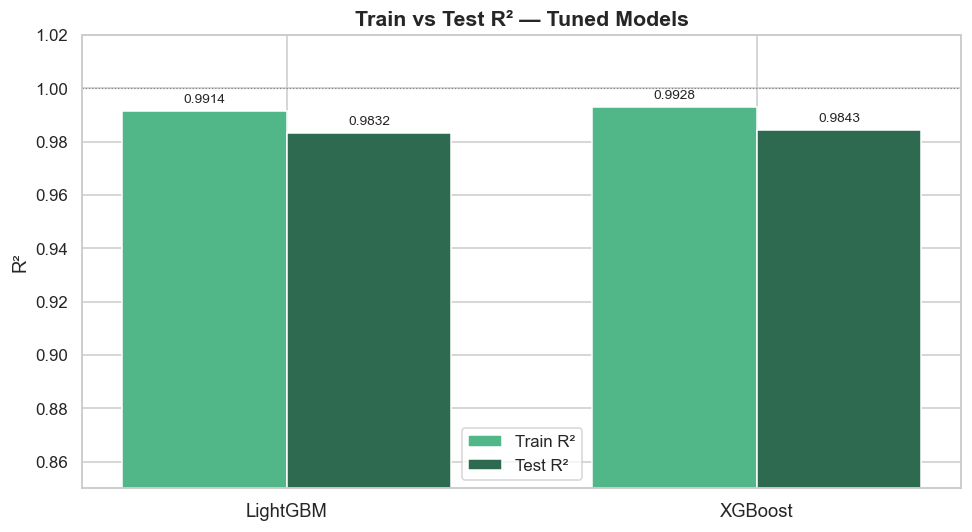

In [36]:
x  = np.arange(len(train_test_df))
w  = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, train_test_df["Train_R2"], w, label="Train R²", color="#52b788", edgecolor="white")
bars2 = ax.bar(x + w/2, train_test_df["Test_R2"],  w, label="Test R²",  color="#2d6a4f", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(train_test_df["Model"], fontsize=12)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("Train vs Test R² — Tuned Models", fontsize=14, fontweight="bold")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


# **Actual vs Predicted — All 3 tuned models**

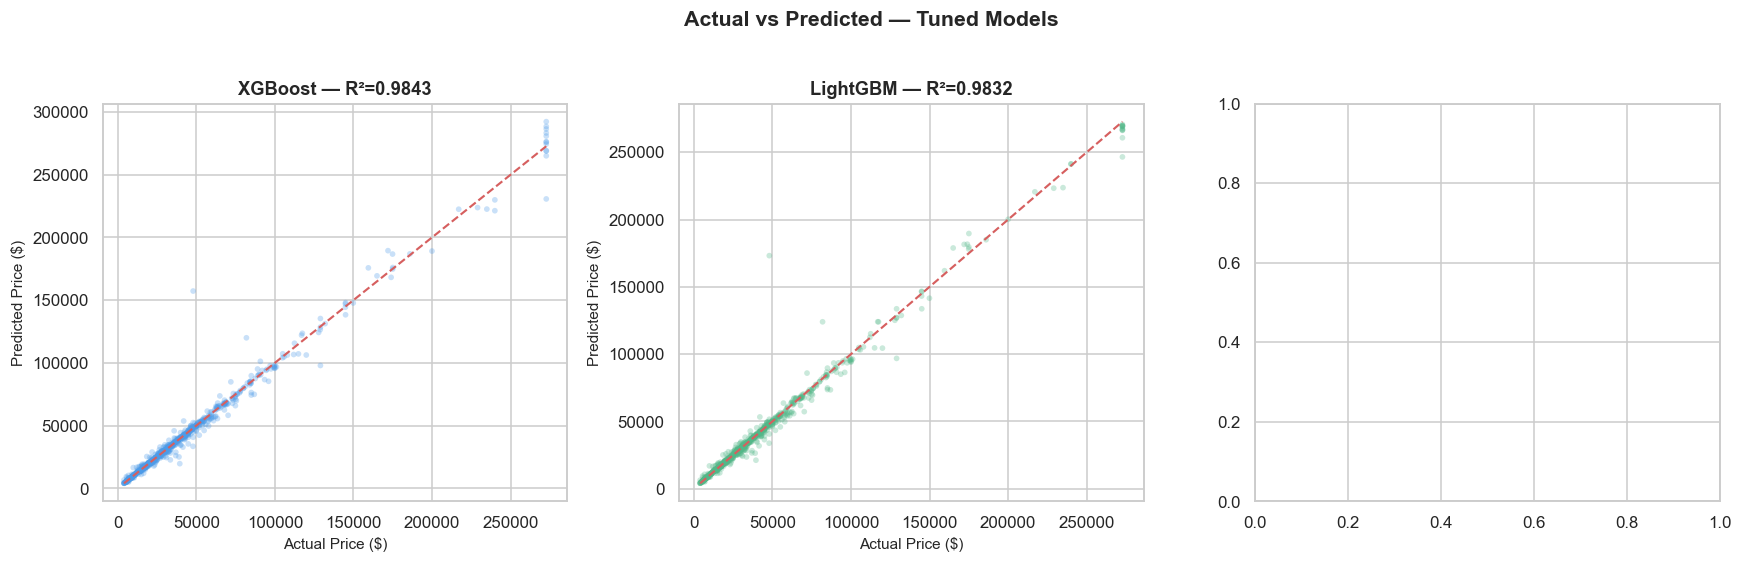

In [39]:
tuned_preds = {
    "XGBoost":  np.expm1(best_xgb.predict(X_test_sklearn)),
    "LightGBM": np.expm1(best_lgb.predict(X_test_sklearn)),
    # "CatBoost": np.expm1(best_cat.predict(X_test_cat)),
}
y_test_real = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_scatter = ["#4c9be8", "#52b788", "#e07b54"]

for ax, (name, preds), color in zip(axes, tuned_preds.items(), colors_scatter):
    r2 = r2_score(y_test_real, preds)
    ax.scatter(y_test_real, preds, alpha=0.3, s=14, color=color, edgecolors="none")
    mn, mx = y_test_real.min(), y_test_real.max()
    ax.plot([mn, mx], [mn, mx], "--r", linewidth=1.4)
    ax.set_xlabel("Actual Price ($)", fontsize=10)
    ax.set_ylabel("Predicted Price ($)", fontsize=10)
    ax.set_title(f"{name} — R²={r2:.4f}", fontsize=12, fontweight="bold")

plt.suptitle("Actual vs Predicted — Tuned Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# **Residual analysis — All 3 tuned models**

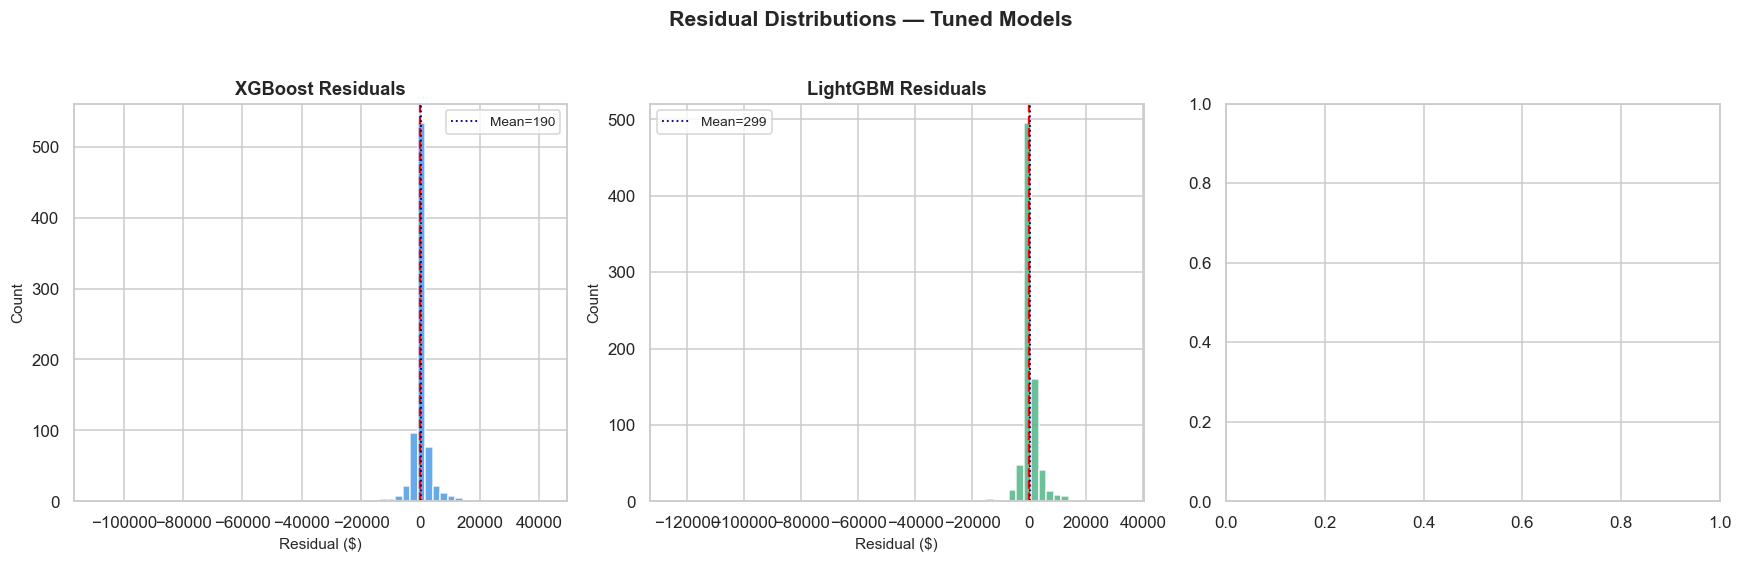

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_res = ["#4c9be8", "#52b788", "#e07b54"]

for ax, (name, preds), color in zip(axes, tuned_preds.items(), colors_res):
    residuals = y_test_real - preds
    ax.hist(residuals, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0,               color="red",  linestyle="--", linewidth=1.5)
    ax.axvline(residuals.mean(), color="navy", linestyle=":",  linewidth=1.2, label=f"Mean={residuals.mean():,.0f}")
    ax.set_xlabel("Residual ($)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"{name} Residuals", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Residual Distributions — Tuned Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# **Feature importance — Tuned models**

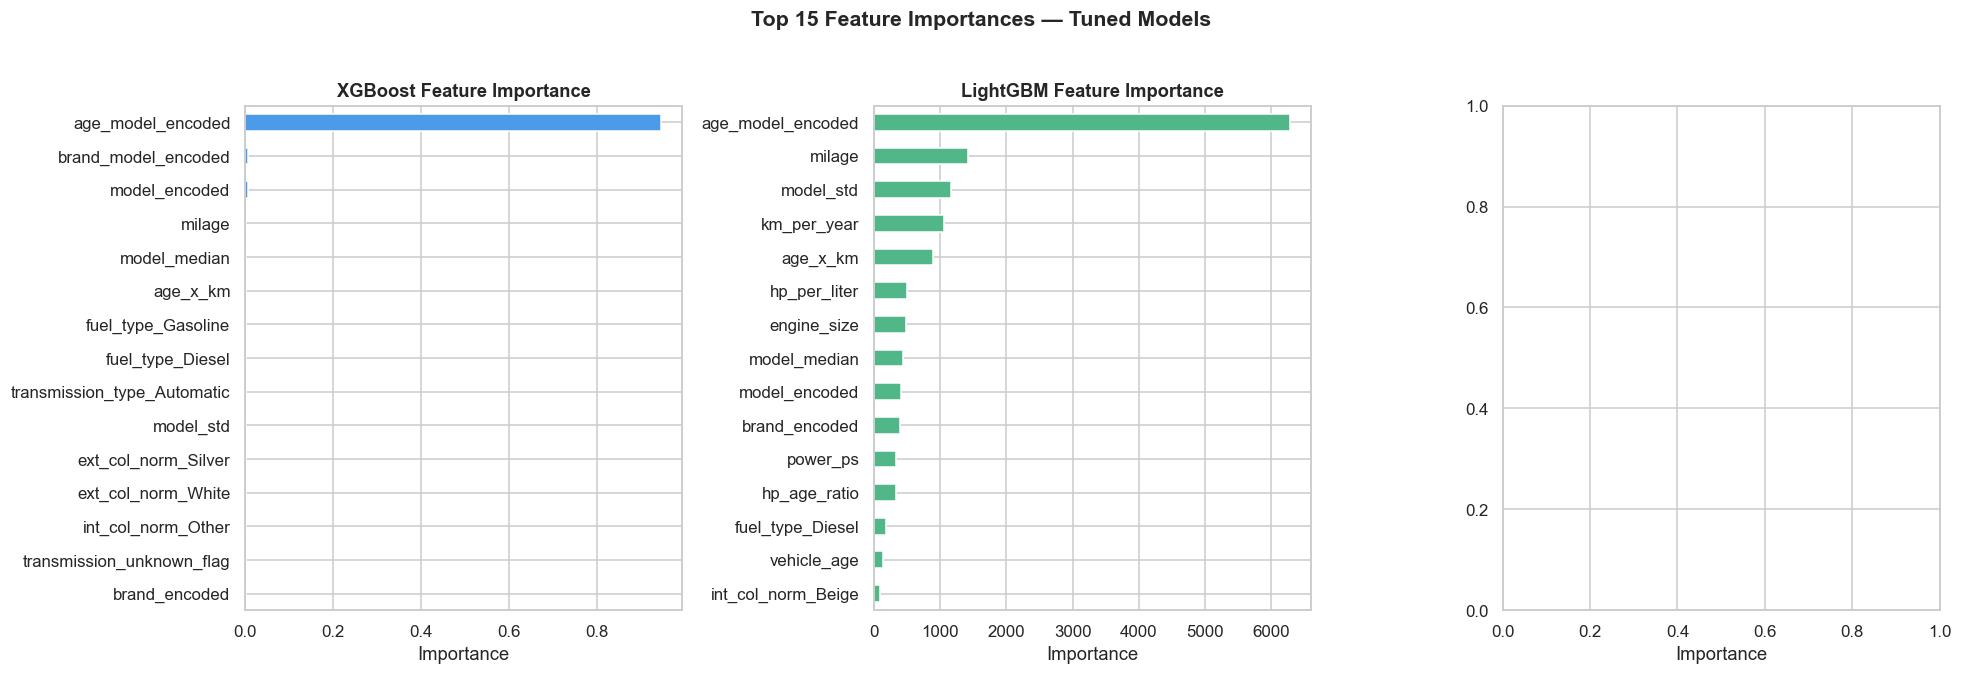

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
xgb_imp = pd.Series(best_xgb.feature_importances_,
                     index=num_cols + list(encoder.get_feature_names_out(cat_cols))
                     ).sort_values().tail(15)
xgb_imp.plot(kind="barh", ax=axes[0], color="#4c9be8")
axes[0].set_title("XGBoost Feature Importance", fontsize=12, fontweight="bold")

# LightGBM
lgb_imp = pd.Series(best_lgb.feature_importances_,
                     index=num_cols + list(encoder.get_feature_names_out(cat_cols))
                     ).sort_values().tail(15)
lgb_imp.plot(kind="barh", ax=axes[1], color="#52b788")
axes[1].set_title("LightGBM Feature Importance", fontsize=12, fontweight="bold")

# CatBoost
# cat_feat_names = list(X_train_cat.columns)
# cat_imp = pd.Series(best_cat.get_feature_importance(),
#                      index=cat_feat_names).sort_values().tail(15)
# cat_imp.plot(kind="barh", ax=axes[2], color="#e07b54")
# axes[2].set_title("CatBoost Feature Importance", fontsize=12, fontweight="bold")

for ax in axes:
    ax.set_xlabel("Importance")

plt.suptitle("Top 15 Feature Importances — Tuned Models",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# **5-Fold cross-validation — Tuned models**

In [42]:
cv_results = []

for name, model, X_cv in [
    ("XGBoost",  best_xgb, X_train_sklearn),
    ("LightGBM", best_lgb, X_train_sklearn),
]:
    scores = cross_val_score(model, X_cv, y_train, cv=5, scoring="r2")
    cv_results.append({"Model": name, "CV Mean R²": scores.mean(), "CV Std": scores.std()})
    print(f"{name:15s}  CV R² = {scores.mean():.4f} ± {scores.std():.4f}  | folds: {scores.round(4)}")

# # CatBoost CV manually
# from sklearn.model_selection import KFold
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# cat_cv_scores = []
# for tr_idx, val_idx in kf.split(X_train_cat):
#     Xtr = X_train_cat.iloc[tr_idx]; Xval = X_train_cat.iloc[val_idx]
#     ytr = y_train.iloc[tr_idx];     yval = y_train.iloc[val_idx]
#     m = CatBoostRegressor(**best_cat.get_params(), silent=True)
#     m.fit(Xtr, ytr, cat_features=cat_cols)
#     preds = np.expm1(m.predict(Xval))
#     cat_cv_scores.append(r2_score(np.expm1(yval), preds))

# cat_cv_scores = np.array(cat_cv_scores)
# cv_results.append({"Model": "CatBoost", "CV Mean R²": cat_cv_scores.mean(), "CV Std": cat_cv_scores.std()})
# print(f"{'CatBoost':15s}  CV R² = {cat_cv_scores.mean():.4f} ± {cat_cv_scores.std():.4f}  | folds: {cat_cv_scores.round(4)}")

cv_df = pd.DataFrame(cv_results).round(4)
cv_df


XGBoost          CV R² = 0.9900 ± 0.0009  | folds: [0.9916 0.9899 0.9895 0.9901 0.9889]
LightGBM         CV R² = 0.9896 ± 0.0009  | folds: [0.991  0.9891 0.9893 0.9902 0.9884]


,Model,CV Mean R²,CV Std
0,XGBoost,0.9900,0.0009
1,LightGBM,0.9896,0.0009


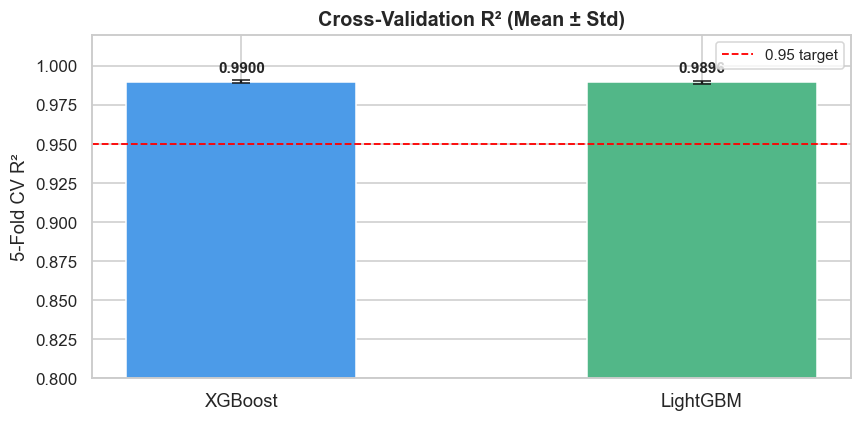

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(cv_df))
ax.bar(x, cv_df["CV Mean R²"], yerr=cv_df["CV Std"], capsize=6,
       color=["#4c9be8","#52b788","#e07b54"], edgecolor="white", width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cv_df["Model"], fontsize=12)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel("5-Fold CV R²", fontsize=12)
ax.set_title("Cross-Validation R² (Mean ± Std)", fontsize=13, fontweight="bold")
ax.axhline(0.95, color="red", linestyle="--", linewidth=1.2, label="0.95 target")
ax.legend(fontsize=10)

for i, (r, s) in enumerate(zip(cv_df["CV Mean R²"], cv_df["CV Std"])):
    ax.text(i, r + s + 0.005, f"{r:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


# **Final summary — Baseline vs Tuned**

In [44]:
# Merge baseline and tuned for side-by-side comparison
baseline_map = results_df.set_index("Model")[["R2","MAE","RMSE"]]
tuned_map    = final_results_df.copy()
tuned_map["Model_base"] = tuned_map["Model"].str.replace(" (Tuned)", "", regex=False)

summary_rows = []
for _, row in tuned_map.iterrows():
    base_name = row["Model_base"]
    if base_name in baseline_map.index:
        summary_rows.append({
            "Model":        row["Model"],
            "Baseline R²":  baseline_map.loc[base_name, "R2"],
            "Tuned R²":     row["R2"],
            "Δ R²":         round(row["R2"] - baseline_map.loc[base_name, "R2"], 4),
            "Tuned MAE":    row["MAE"],
            "Tuned RMSE":   row["RMSE"],
        })

summary_df = pd.DataFrame(summary_rows).sort_values("Tuned R²", ascending=False)
print(summary_df.to_string(index=False))
summary_df


           Model  Baseline R²  Tuned R²   Δ R²  Tuned MAE  Tuned RMSE
 XGBoost (Tuned)       0.9758    0.9843 0.0085    1920.89     5497.24
LightGBM (Tuned)       0.9825    0.9832 0.0007    1841.50     5680.67


,Model,Baseline R²,Tuned R²,Δ R²,Tuned MAE,Tuned RMSE
0,XGBoost (Tuned),0.9758,0.9843,0.0085,1920.89,5497.24
1,LightGBM (Tuned),0.9825,0.9832,0.0007,1841.50,5680.67


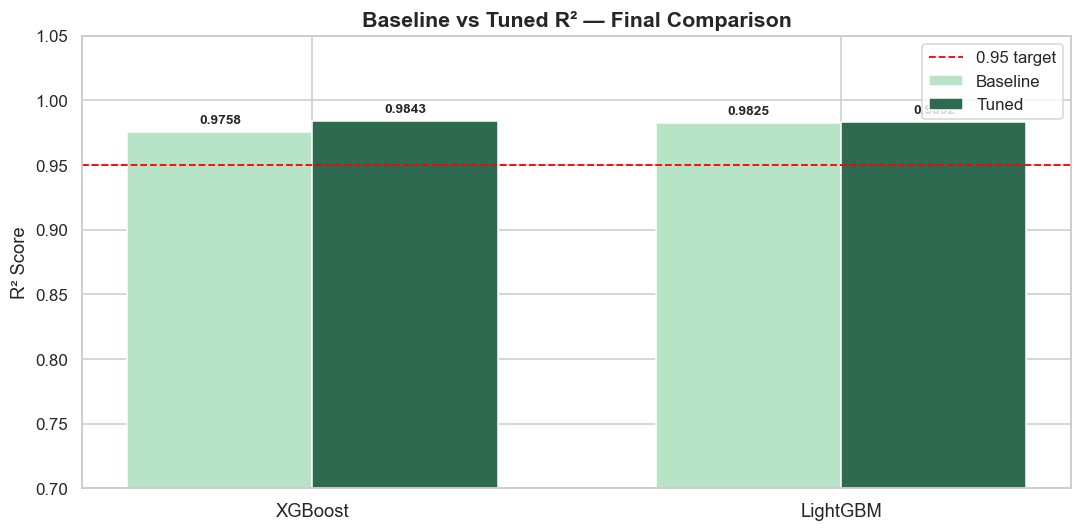

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(summary_df))
w  = 0.35

b1 = ax.bar(x - w/2, summary_df["Baseline R²"], w, label="Baseline", color="#b7e4c7", edgecolor="white")
b2 = ax.bar(x + w/2, summary_df["Tuned R²"],    w, label="Tuned",    color="#2d6a4f", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(summary_df["Model"].str.replace(" (Tuned)","",regex=False), fontsize=12)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel("R² Score", fontsize=12)
ax.set_title("Baseline vs Tuned R² — Final Comparison", fontsize=14, fontweight="bold")
ax.axhline(0.95, color="red", linestyle="--", linewidth=1.2, label="0.95 target")
ax.legend(fontsize=11)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()
